# Credit Spread Regime Detection & Signal Backtest

This notebook builds a regime-aware credit signal using Hidden Markov Models on US IG and HY OAS spreads.
The core thesis: credit spreads cluster into distinct regimes (tight/stable, widening/stress, recovery) that
exhibit persistence and predictability. A regime-aware positioning strategy should outperform static rules
on a risk-adjusted basis.

**Data**: ICE BofA IG and HY OAS from FRED (free, no API key required for public series)  
**Model**: Gaussian HMM (3 states) via `hmmlearn`  
**Backtest**: Regime-conditional long/short credit signal, evaluated on Sharpe and max drawdown

## 0. Dependencies

In [2]:
# Install if needed
!pip install hmmlearn pandas-datareader fredapi matplotlib seaborn scipy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats

from hmmlearn.hmm import GaussianHMM
import pandas_datareader.data as web
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11

print('Libraries loaded.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 4.3 MB/s eta 0:00:00
Libraries loaded.


## 1. Data Pull — FRED (ICE BofA OAS)

We use two series:
- `BAMLC0A0CM` — ICE BofA US Corporate (IG) OAS
- `BAMLH0A0HYM2` — ICE BofA US High Yield OAS

No API key needed for FRED public series via `pandas_datareader`.

In [3]:
START = '2000-01-01'
END   = '2024-12-31'

ig = web.DataReader('BAMLC0A0CM',    'fred', START, END).rename(columns={'BAMLC0A0CM': 'IG_OAS'})
hy = web.DataReader('BAMLH0A0HYM2',  'fred', START, END).rename(columns={'BAMLH0A0HYM2': 'HY_OAS'})

df = ig.join(hy, how='inner').dropna()
df['HY_IG_ratio'] = df['HY_OAS'] / df['IG_OAS']   # cross-asset stress indicator

print(f'Observations: {len(df):,}  |  {df.index[0].date()} → {df.index[-1].date()}')
df.head()

Observations: 6,526  |  2000-01-03 → 2024-12-31


,IG_OAS,HY_OAS,HY_IG_ratio
DATE,,,
2000-01-03,1.16,4.68,4.034483
2000-01-04,1.16,4.81,4.146552
2000-01-05,1.18,4.77,4.042373
2000-01-06,1.18,4.82,4.084746
2000-01-07,1.20,4.86,4.050000


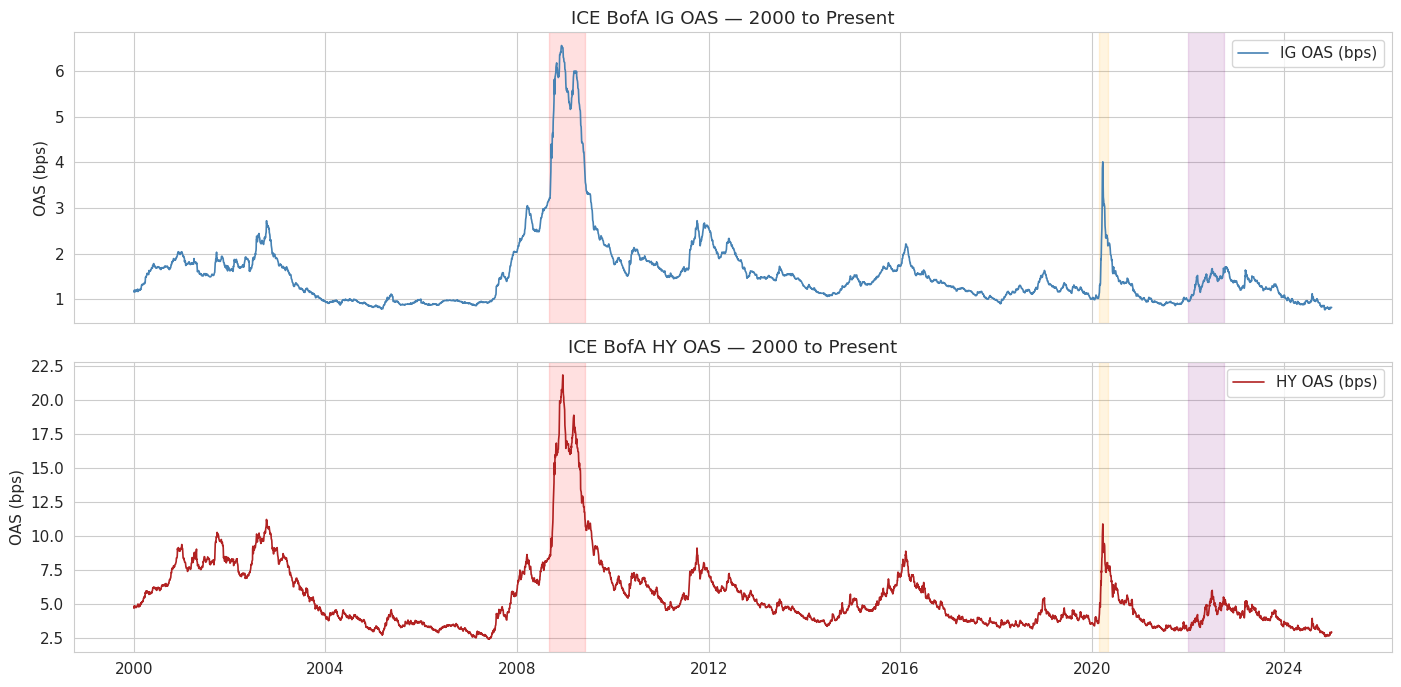

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(df.index, df['IG_OAS'], color='steelblue', lw=1.2, label='IG OAS (bps)')
axes[0].set_ylabel('OAS (bps)')
axes[0].set_title('ICE BofA IG OAS — 2000 to Present')
axes[0].legend()

axes[1].plot(df.index, df['HY_OAS'], color='firebrick', lw=1.2, label='HY OAS (bps)')
axes[1].set_ylabel('OAS (bps)')
axes[1].set_title('ICE BofA HY OAS — 2000 to Present')
axes[1].legend()

# Annotate key stress events
for ax in axes:
    ax.axvspan('2008-09-01', '2009-06-01', alpha=0.12, color='red', label='GFC')
    ax.axvspan('2020-02-20', '2020-05-01', alpha=0.12, color='orange', label='COVID')
    ax.axvspan('2022-01-01', '2022-10-01', alpha=0.12, color='purple', label='Rate Shock')

plt.tight_layout()
plt.show()

## 2. Feature Engineering

We construct features that capture **level, momentum, and volatility** of credit spreads.
HMM states are driven by these features rather than raw OAS to improve regime stability.

In [5]:
feat = pd.DataFrame(index=df.index)

# 1. Daily change in IG OAS (momentum)
feat['dIG']         = df['IG_OAS'].diff()

# 2. 21-day rolling z-score of IG OAS (relative level)
feat['IG_zscore']   = (df['IG_OAS'] - df['IG_OAS'].rolling(252).mean()) / df['IG_OAS'].rolling(252).std()

# 3. 21-day realized vol of IG OAS changes
feat['IG_vol21']    = feat['dIG'].rolling(21).std()

# 4. HY-IG ratio momentum (cross-asset risk-on/off)
feat['ratio_mom']   = df['HY_IG_ratio'].diff(5)   # 1-week change

feat = feat.dropna()
X = feat.values

print(f'Feature matrix shape: {X.shape}')
feat.describe().round(3)

Feature matrix shape: (6275, 4)


,dIG,IG_zscore,IG_vol21,ratio_mom
count,6275.000,6275.000,6275.000,6275.000
mean,-0.000,-0.106,0.016,-0.001
std,0.026,1.482,0.018,0.106
min,-0.330,-2.906,0.002,-0.676
25%,-0.010,-1.257,0.008,-0.060
50%,0.000,-0.408,0.011,-0.001
75%,0.010,0.896,0.016,0.059
max,0.480,8.340,0.210,0.663


## 3. Hidden Markov Model — Regime Detection

We fit a **3-state Gaussian HMM** on the feature matrix. Three states maps naturally to:
- **State 0** — Tight / benign (low spreads, low vol)
- **State 1** — Widening / stress (rising spreads, elevated vol)
- **State 2** — Recovery / compression (falling spreads from elevated levels)

Note: HMM states are unlabeled post-fit — we assign economic meaning by inspecting posterior means.

In [6]:
N_STATES = 3
RANDOM_SEED = 42

model = GaussianHMM(
    n_components=N_STATES,
    covariance_type='full',
    n_iter=1000,
    random_state=RANDOM_SEED
)
model.fit(X)

hidden_states = model.predict(X)
state_probs   = model.predict_proba(X)

print(f'Model converged: {model.monitor_.converged}')
print(f'Log-likelihood:  {model.score(X):.2f}')
print(f'\nTransition matrix:')
print(pd.DataFrame(model.transmat_.round(3),
                   index=[f'From S{i}' for i in range(N_STATES)],
                   columns=[f'To S{i}' for i in range(N_STATES)]))

Model converged: True
Log-likelihood:  39599.06

Transition matrix:
         To S0  To S1  To S2
From S0  0.992  0.005  0.002
From S1  0.009  0.982  0.009
From S2  0.003  0.033  0.964


In [7]:
# Attach regimes back to aligned dataframe
aligned = df.loc[feat.index].copy()
aligned['regime']      = hidden_states
aligned['state_probs'] = [state_probs[i] for i in range(len(state_probs))]

# Label regimes by IG OAS mean (lowest spread = benign, highest = stress)
regime_means = aligned.groupby('regime')['IG_OAS'].mean().sort_values()
label_map = {
    regime_means.index[0]: 'Tight',
    regime_means.index[1]: 'Recovery',
    regime_means.index[2]: 'Stress'
}
aligned['regime_label'] = aligned['regime'].map(label_map)

print('Regime distribution:')
print(aligned['regime_label'].value_counts(normalize=True).round(3))

Regime distribution:
regime_label
Tight       0.475
Recovery    0.393
Stress      0.133
Name: proportion, dtype: float64


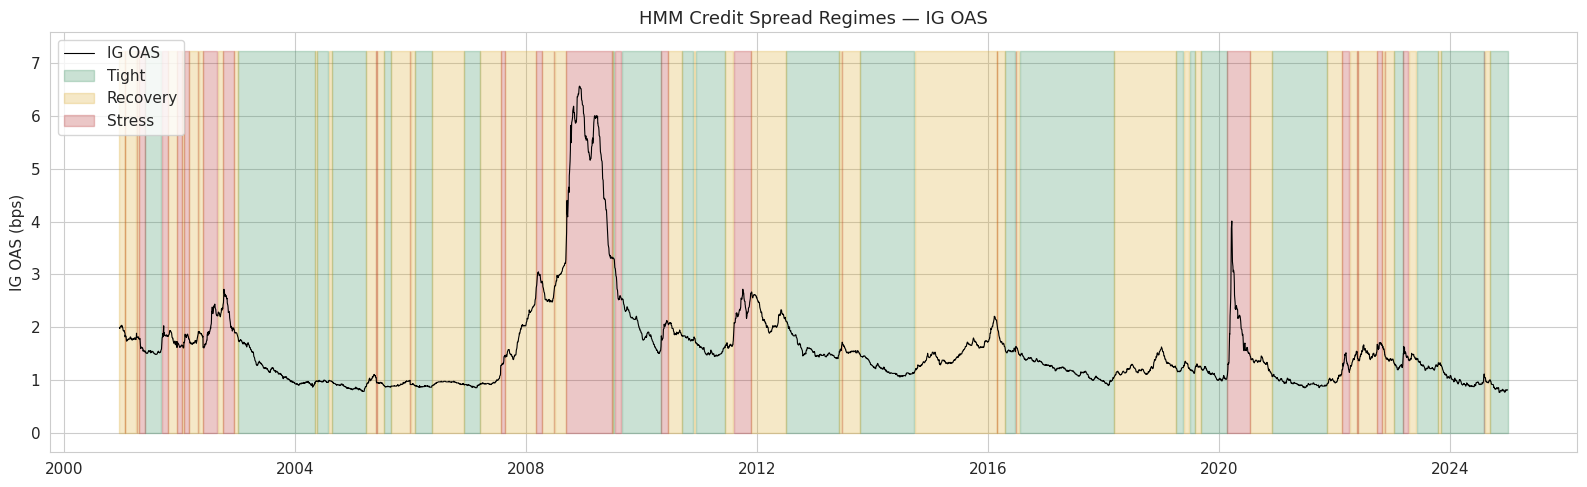

In [8]:
COLORS = {'Tight': 'seagreen', 'Recovery': 'goldenrod', 'Stress': 'firebrick'}

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(aligned.index, aligned['IG_OAS'], color='black', lw=0.8, zorder=5, label='IG OAS')

# Shade by regime
for label, color in COLORS.items():
    mask = aligned['regime_label'] == label
    ax.fill_between(aligned.index, 0, aligned['IG_OAS'].max() * 1.1,
                    where=mask, alpha=0.25, color=color, label=label)

ax.set_ylabel('IG OAS (bps)')
ax.set_title('HMM Credit Spread Regimes — IG OAS', fontsize=13)
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

## 4. Regime Characterization

Validate that detected regimes align with economic intuition.

In [9]:
summary = aligned.groupby('regime_label').agg(
    IG_OAS_mean   = ('IG_OAS',  'mean'),
    IG_OAS_median = ('IG_OAS',  'median'),
    HY_OAS_mean   = ('HY_OAS',  'mean'),
    HY_IG_ratio   = ('HY_IG_ratio', 'mean'),
    days          = ('IG_OAS',  'count')
).round(2)

summary['pct_time'] = (summary['days'] / summary['days'].sum() * 100).round(1)
print(summary.to_string())

              IG_OAS_mean  IG_OAS_median  HY_OAS_mean  HY_IG_ratio  days  pct_time
regime_label                                                                      
Recovery             1.52           1.45         5.17         3.42  2463      39.3
Stress               2.84           2.24         9.49         3.55   832      13.3
Tight                1.24           1.17         4.49         3.63  2980      47.5


## 5. Backtest — Regime-Conditional Credit Signal

**Signal logic:**
- `Tight` regime → **Long credit** (collect carry, spreads stable/tightening)
- `Recovery` regime → **Long credit** (spreads compressing from stress)
- `Stress` regime → **Short credit / flat** (spreads widening, drawdown risk)

We proxy credit returns using daily change in IG OAS (negative = spread tightening = positive P&L for long credit).
This is a first-order approximation; a real desk would use CDX IG total return or cash bond returns.

**Execution assumption:** 1-day signal lag (regime on day T → position on day T+1).

In [10]:
bt = aligned.copy()

# Proxy daily credit return: spread tightening = positive for long credit
bt['credit_return'] = -bt['IG_OAS'].diff()          # bps P&L per unit notional

# Signal: +1 (long) in Tight/Recovery, -1 (short/flat) in Stress
# Lagged by 1 day to avoid look-ahead
bt['signal'] = bt['regime_label'].map({'Tight': 1, 'Recovery': 1, 'Stress': -1})
bt['signal'] = bt['signal'].shift(1)

# Strategy return
bt['strat_return']  = bt['signal'] * bt['credit_return']
bt['bh_return']     = bt['credit_return']   # Buy-and-hold benchmark

# Cumulative P&L (bps)
bt['cum_strat'] = bt['strat_return'].cumsum()
bt['cum_bh']    = bt['bh_return'].cumsum()

bt = bt.dropna(subset=['strat_return'])
print('Backtest ready.')

Backtest ready.


In [11]:
def sharpe(returns, periods=252):
    return np.sqrt(periods) * returns.mean() / returns.std()

def max_drawdown(cum_returns):
    roll_max = cum_returns.cummax()
    drawdown = cum_returns - roll_max
    return drawdown.min()

def calmar(returns, cum_returns, periods=252):
    ann_return = returns.mean() * periods
    mdd = abs(max_drawdown(cum_returns))
    return ann_return / mdd if mdd != 0 else np.nan

metrics = pd.DataFrame({
    'Strategy': [
        sharpe(bt['strat_return']),
        max_drawdown(bt['cum_strat']),
        calmar(bt['strat_return'], bt['cum_strat']),
        bt['strat_return'].sum()
    ],
    'Buy & Hold': [
        sharpe(bt['bh_return']),
        max_drawdown(bt['cum_bh']),
        calmar(bt['bh_return'], bt['cum_bh']),
        bt['bh_return'].sum()
    ]
}, index=['Sharpe Ratio', 'Max Drawdown (bps)', 'Calmar Ratio', 'Total P&L (bps)'])

print(metrics.round(3).to_string())

                    Strategy  Buy & Hold
Sharpe Ratio           0.364       0.112
Max Drawdown (bps)    -3.860      -5.770
Calmar Ratio           0.039       0.008
Total P&L (bps)        3.790       1.170


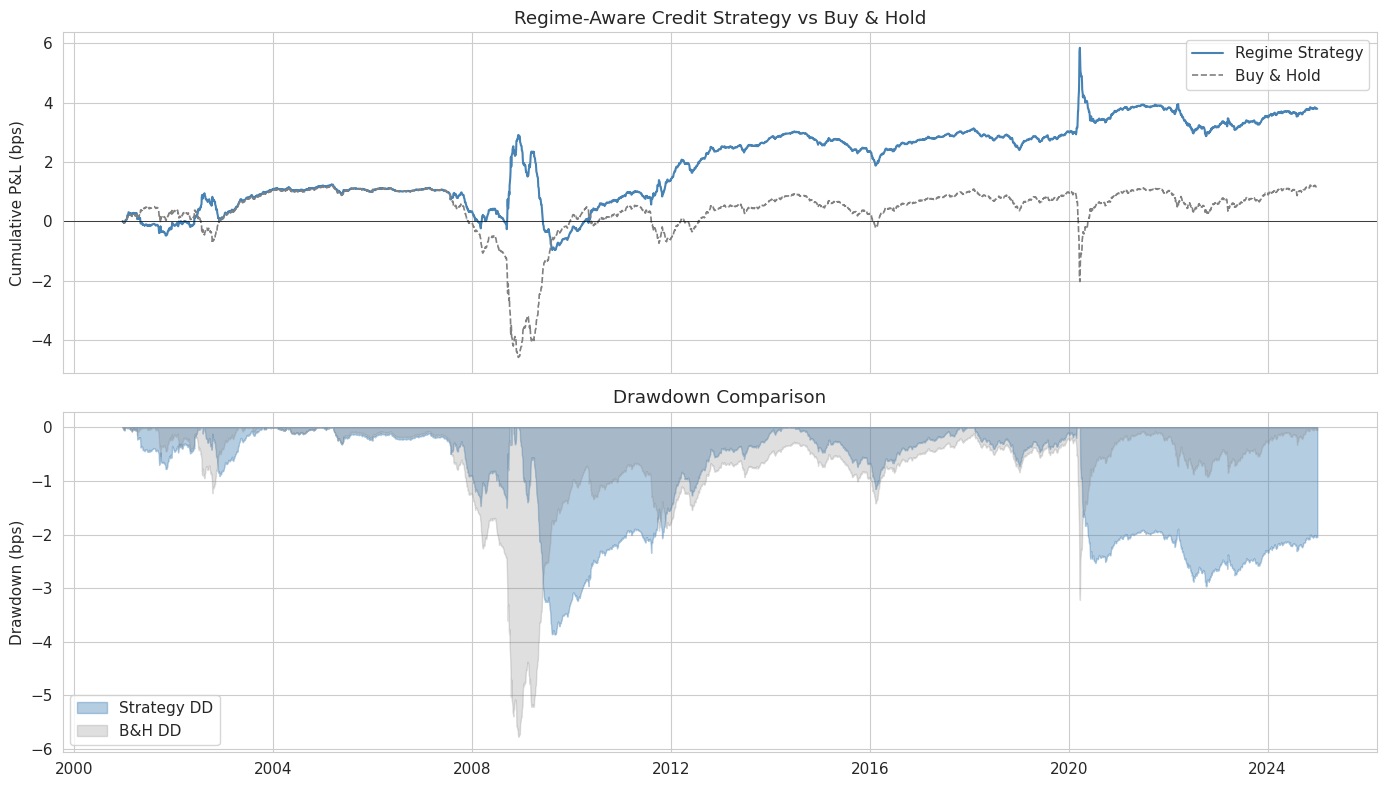

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Cumulative P&L
axes[0].plot(bt.index, bt['cum_strat'], color='steelblue', lw=1.5, label='Regime Strategy')
axes[0].plot(bt.index, bt['cum_bh'],   color='grey',      lw=1.2, ls='--', label='Buy & Hold')
axes[0].axhline(0, color='black', lw=0.5)
axes[0].set_ylabel('Cumulative P&L (bps)')
axes[0].set_title('Regime-Aware Credit Strategy vs Buy & Hold')
axes[0].legend()

# Drawdown
strat_dd = bt['cum_strat'] - bt['cum_strat'].cummax()
bh_dd    = bt['cum_bh']   - bt['cum_bh'].cummax()
axes[1].fill_between(bt.index, strat_dd, 0, alpha=0.4, color='steelblue', label='Strategy DD')
axes[1].fill_between(bt.index, bh_dd,   0, alpha=0.25, color='grey',      label='B&H DD')
axes[1].set_ylabel('Drawdown (bps)')
axes[1].set_title('Drawdown Comparison')
axes[1].legend()

plt.tight_layout()
plt.show()

## 6. Regime Persistence Analysis

A key property of a tradeable regime signal is **persistence** — regimes should last long enough
to act on. We check average regime duration and transition probabilities.

Regime Duration Statistics:
              Mean Duration (days)  Median Duration (days)  Max Duration (days)
regime_label                                                                   
Recovery                      58.6                    35.5                  371
Stress                        29.7                    21.0                  210
Tight                        129.6                    77.0                  427


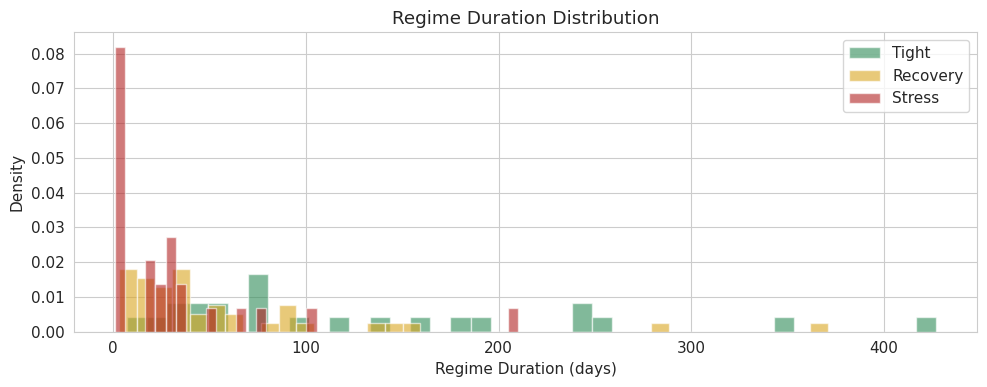

In [13]:
# Compute regime run lengths
bt['regime_change'] = (bt['regime_label'] != bt['regime_label'].shift(1)).astype(int)
bt['run_id'] = bt['regime_change'].cumsum()

run_lengths = bt.groupby(['run_id', 'regime_label']).size().reset_index(name='duration')

duration_stats = run_lengths.groupby('regime_label')['duration'].agg(['mean', 'median', 'max']).round(1)
duration_stats.columns = ['Mean Duration (days)', 'Median Duration (days)', 'Max Duration (days)']
print('Regime Duration Statistics:')
print(duration_stats.to_string())

# Viz
fig, ax = plt.subplots(figsize=(10, 4))
for label, color in COLORS.items():
    data = run_lengths[run_lengths['regime_label'] == label]['duration']
    ax.hist(data, bins=40, alpha=0.6, color=color, label=label, density=True)
ax.set_xlabel('Regime Duration (days)')
ax.set_ylabel('Density')
ax.set_title('Regime Duration Distribution')
ax.legend()
plt.tight_layout()
plt.show()

## 7. Extensions & Next Steps

This notebook establishes a baseline. Productive extensions for a desk context:

1. **CDX total return proxy**: Replace OAS change with CDX IG on-the-run total return for more realistic P&L
2. **Regime probability threshold**: Only trade when posterior probability > 70% to filter noisy regime switches
3. **Multi-factor features**: Add equity vol (VIX), rates vol (MOVE index), and loan-level data
4. **Out-of-sample validation**: Walk-forward with rolling 3-year training windows
5. **Transaction cost sensitivity**: CDX bid-ask ~0.5bps — test at what turnover rate costs erode alpha
6. **Sector decomposition**: Run separate HMMs on IG sector sub-indices (financials vs industrials vs energy)

---
*Data: FRED / ICE BofA. Model: Gaussian HMM via hmmlearn. This is a research prototype, not investment advice.*